ＡIプログラミング2 5,6回目<br>

# 6.softmax関数

(1)1次元の時（こちらが基本です)

In [4]:
#1次元のみ
import torch
from torch import nn
import matplotlib.pylab as plt

L=[-3, -5, 1.0]
Z=torch.tensor(L)

#次元軸についてsoftmaxを計算
m = nn.Softmax(dim=0)

y=m(Z)

print("softmax:",y)
print("softmaxの合計",y.sum())

softmax: tensor([0.0179, 0.0024, 0.9796])
softmaxの合計 tensor(1.)


(2)2次元の時（応用編)

In [2]:
#2次元
import torch
from torch import nn
import matplotlib.pylab as plt

M=[[3,5,1.0], [-3,2,-1]]
Z=torch.tensor(M)

#計算する方向を指定
m = nn.Softmax(dim=1)

y=m(Z)

print("softmax:\n",y)


softmax:
 tensor([[0.1173, 0.8668, 0.0159],
        [0.0064, 0.9465, 0.0471]])


# 7.損失関数

(1)平均二乗誤差 $E=\frac{1}{n}\Sigma_{k=1}^{n}(y_k -t_k)^2$

In [5]:
import torch
from torch import nn

y=[0.1, 0.7, 0.2]
t=[0,    1,   0]

y=torch.tensor(y)
t=torch.tensor(t)

loss_func = nn.MSELoss()

loss = loss_func(y,t)

print("loss:", loss.item())

loss: 0.046666666865348816


(2)交差エントロピー　$E=-\Sigma_{k}^{n}(t_k \log y_k)$

In [6]:
import torch
from torch import nn

y=[0.1, 0.7, 0.2]
#t=[0, 1, 0] のところを、1番目が1であるようにする。
t=1

#tensorに変えてからlogを計算
y=torch.log(torch.tensor(y))
t=torch.tensor(t)

#クロスエントロピー誤差の計算
loss_func = nn.CrossEntropyLoss()
loss = loss_func(y,t)

print("loss:", loss.item())

loss: 0.3566748797893524


In [7]:
#nn.CrossEntorpyLossを使わない場合
import torch
#from torch import nn

y=[0.1, 0.7, 0.2]
t=[0, 1, 0]       #t=1

y=torch.tensor(y)
t=torch.tensor(t)

#各要素のlogを計算、合計した後に-1かける
l=t*torch.log(y)
loss=-torch.sum(l)

print("l=",l)
print("loss=",loss)

l= tensor([-0.0000, -0.3567, -0.0000])
loss= tensor(0.3567)


#課題3

入力X,重みW1,バイアスb1としたときに<br>
順伝搬の結果をsoftmaxで処理した結果を<br>
出力する

In [33]:
#入力X,重みW1,バイアスb1部分
#入力 ここでは3次元
x=[1,1,0.0]
#重みとバイアスの設定
w1=[[1,4],[0,0],[6,1.0]]
b1=2.0


#テンソルへの変換
X = torch.tensor(x)
W1 = torch.tensor(w1)
#B1=b1*torch.tensor([1.0, 1.0])
B1 = b1*torch.full((2,), 1.0)

#順伝搬の計算　3x(3,2)+(2)→2次元
Z1 = torch.matmul(X, W1)+B1
print("Z1:", Z1)

#Z1のソフトマックスの計算
m=nn.Softmax()
y=m(Z1)

print("y=",y)

Z1: tensor([3., 6.])
y= tensor([0.0474, 0.9526])


#課題4<br>
x(3要素), W1(3,2), b1(2)を定義し、平均2乗誤差を求める

In [34]:
#入力データ
x=[1,1,0.0]
#重み
w1=[[1,4],[0,0],[6,1.0]]
b1=3.0
#入力に対する答え　平均2乗誤差
t=[0,1]
#t=1

X = torch.tensor(x)
W1=torch.tensor(w1)
#B1=b1*torch.tensor([1.0, 1.0])
B1=b1*torch.full((2,), 1.0)

Z1=torch.matmul(X, W1)+B1

#Z1のソフトマックスの計算
m=nn.Softmax(dim=0)
y=m(Z1)

print("Z1=",Z1)
print("y=",y)


t=torch.tensor(t)

loss_func = nn.MSELoss()
loss = loss_func(y,t)

print("y:",y, "t:",t)
print("loss:", loss.item())


Z1= tensor([4., 7.])
y= tensor([0.0474, 0.9526])
y: tensor([0.0474, 0.9526]) t: tensor([0, 1])
loss: 0.002249212935566902


#課題5<br>
x(3要素), W1(3,2), b1(2)を定義し、CrossEntorpyErrorを求める。<br>
データは課題4と同じでよい。

In [36]:
#入力データ
x=[1,1,0.0]
#重み
w1=[[1,4],[0,0],[6,1.0]]
b1=3.0
#入力に対する答え　平均2乗誤差
#t=[0,1]
t= 1

X=torch.tensor(x)
W1=torch.tensor(w1)
#B1=b1*torch.tensor([1.0, 1.0])
B1=b1*torch.full((2,), 1.0)

Z1=torch.matmul(X,W1)+B1

#Z1のソフトマックスの計算
m=nn.Softmax(dim=0)
y=m(Z1)

print("Z1=",Z1)
print("y=",y)

#tensorに変えてからlogを計算
y=torch.log(torch.tensor(y))
t=torch.tensor(t)
#クロスエントロピー誤差の計算
loss_func = nn.CrossEntropyLoss()
loss = loss_func(y,t)


print("y:",y, "t:",t)
print("loss:", loss.item())


Z1= tensor([4., 7.])
y= tensor([0.0474, 0.9526])
y: tensor([-3.0486, -0.0486]) t: tensor(1)
loss: 0.04858732968568802


<ipython-input-36-184a405aa789>:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y=torch.log(torch.tensor(y))


#課題6<br>
L=[]に損失率の数値を複数個用意し、<br>
それをTensorに変換後グラフを描きなさい。

<function matplotlib.pyplot.show(close=None, block=None)>

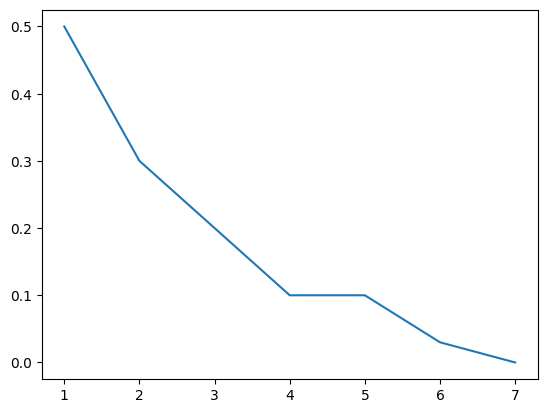

In [52]:
import torch
from torch import nn
import matplotlib.pylab as plt

L=[0.5, 0.3,0.2, 0.1, 0.1, 0.03, 0]
loss=torch.tensor(L)
x=torch.linspace(1,len(loss),len(loss))


plt.plot(x,loss)
plt.show

#課題7<br>
複数個の入力データとその正解データtに対して、<br>
Z1=X・W1+b1を計算し、<br>
Z1とtから平均2乗誤差を計算し、グラフ化せよ。

y_i: tensor([0.0207, 0.1175]) ti: tensor([0, 1]) loss yi,ti: tensor(0.3896)
y_i: tensor([0.6853, 0.8680]) ti: tensor([1, 0]) loss yi,ti: tensor(0.4262)
y_i: tensor([0.0153, 0.0058]) ti: tensor([0, 1]) loss yi,ti: tensor(0.4943)
y_i: tensor([0.2786, 0.0087]) ti: tensor([1, 0]) loss yi,ti: tensor(0.2602)
MES: [tensor(0.3896), tensor(0.4262), tensor(0.4943), tensor(0.2602)]


<function matplotlib.pyplot.show(close=None, block=None)>

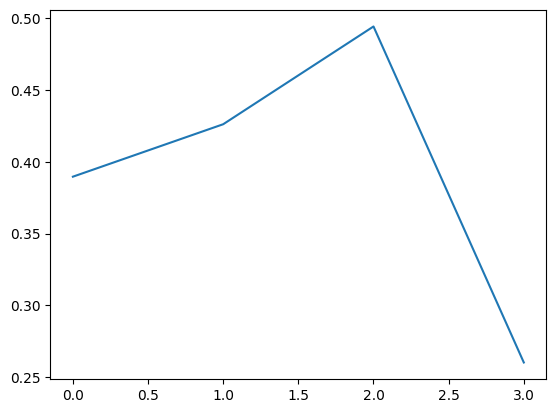

In [ ]:
import torch
from torch import nn
import matplotlib.pylab as plt

#入力データ
x=[[ ], [ ],[ ], [ ]]
t=[[0, 1],   [1,0],        [0, 1],       [1,0]]
#t=[1,1,1,0]
t=torch.tensor(t)

#重み
w1=[[2,5],[0,1],[7,2.0]]
b1=3.0
#入力に対する答え　平均2乗誤差







#順伝搬の計算


#Z1のソフトマックスの計算

y=m(Z1)


loss_func = nn.MSELoss()

#x軸とy軸lossをセット
x=[i for i in range(4)]
loss=[]

#各yとtからMSEを計算
for yi,ti in zip(y,t):
  print("y_i:",yi, "ti:",ti, "loss yi,ti:",loss_func(yi,ti))
  loss.append(loss_func(yi,ti))

print("MES:", loss)

plt.plot(x,loss)
plt.show



#参考
複数個の入力データとその正解データtに対して、
Z1=X・W1+b1を計算し、
Z1とtからCrossEntorpy誤差を計算し、グラフ化せよ。

y_i: tensor([0.0207, 0.1175]) ti: tensor(1) loss yi,ti: tensor(0.6459)
y_i: tensor([0.6853, 0.8680]) ti: tensor(1) loss yi,ti: tensor(0.6060)
y_i: tensor([0.0153, 0.0058]) ti: tensor(1) loss yi,ti: tensor(0.6979)
y_i: tensor([0.2786, 0.0087]) ti: tensor(0) loss yi,ti: tensor(0.5673)
CE: [tensor(0.6459), tensor(0.6060), tensor(0.6979), tensor(0.5673)]


<function matplotlib.pyplot.show(close=None, block=None)>

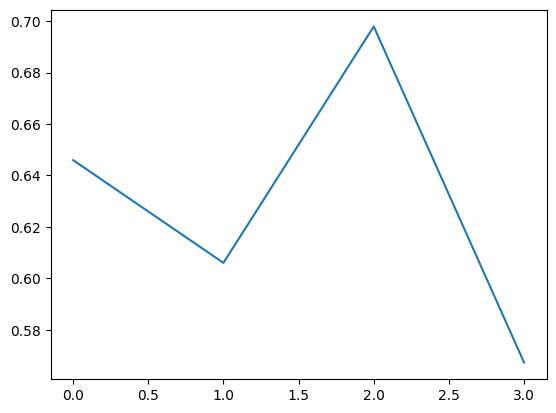

In [ ]:
import torch
from torch import nn
import matplotlib.pylab as plt

#入力データ
x=[[1, 1, 0.0], [1.0, 2.0, 0.5],[0.5, 0.3, 0.1], [0.2,1.2, 0.6]]
#t=[[0, 1],   [1,0],        [0, 1],       [1,0]]
t=[1,1,1,0]
t=torch.tensor(t)

#重み
w1=[[2,5],[0,1],[7,2.0]]
b1=3.0
#入力に対する答え　平均2乗誤差
#t=[0,1]
#t=1

X=torch.tensor(x)
W1=torch.tensor(w1)
#B1=b1*torch.full((2,),1)
B1=b1*torch.tensor([1.0,1])

#順伝搬の計算
Z1=torch.matmul(X,W1)+B1

#Z1のソフトマックスの計算
m=nn.Softmax(dim=0)
y=m(Z1)


loss_func = nn.MSELoss()

#tensorに変えてからlogを計算
#y=torch.log(torch.tensor(y))
#t=torch.tensor(t)

#クロスエントロピー誤差の計算
loss_func = nn.CrossEntropyLoss()
#loss = loss_func(y,t)



#x軸とy軸lossをセット
x=[i for i in range(4)]
loss=[]

#各yとtからMSEを計算
for yi,ti in zip(y,t):
  print("y_i:",yi, "ti:",ti, "loss yi,ti:",loss_func(yi,ti))
  loss.append(loss_func(yi,ti))


print("CE:", loss)

plt.plot(x,loss)
plt.show



